In [10]:
# Import library yang dibutuhkan
!pip install streamlit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import streamlit as st
from datetime import datetime

In [11]:
df = pd.read_csv('online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [13]:
df.shape

(541909, 8)

In [14]:
# 2. Preprocessing
# Ubah InvoiceDate ke datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
# Cek missing value dan duplikat
print("Missing Values:\n", df.isnull().sum())
print("Duplicated Rows:", df.duplicated().sum())

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Duplicated Rows: 5268


In [16]:
# Drop missing CustomerID dan Description
df = df.dropna(subset=['CustomerID', 'Description'])
df = df.drop_duplicates()

In [18]:
df.shape

(401604, 8)

In [19]:
# Cek missing value dan duplikat
print("Missing Values:\n", df.isnull().sum())
print("Duplicated Rows:", df.duplicated().sum())

Missing Values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Duplicated Rows: 0


In [20]:
# Filter transaksi valid (Quantity > 0, UnitPrice > 0)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [21]:
# Tambah kolom TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [22]:
# Cek anomali: InvoiceNo yang dimulai dengan 'C' (cancelled)
df = df[~df['InvoiceNo'].str.startswith('C')]

In [23]:
# Cek data setelah preprocessing
print("Data Shape setelah Preprocessing:", df.shape)
print(df.info())

Data Shape setelah Preprocessing: (392692, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB
None


In [24]:
# 3. Market Basket Analysis
# Filter data UK (fokus ke pasar terbesar)
df_uk = df[df['Country'] == 'United Kingdom']

In [25]:
# Buat basket: pivot table berdasarkan InvoiceNo dan Description
basket = df_uk.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

<ipython-input-25-b9be6a36ca80>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


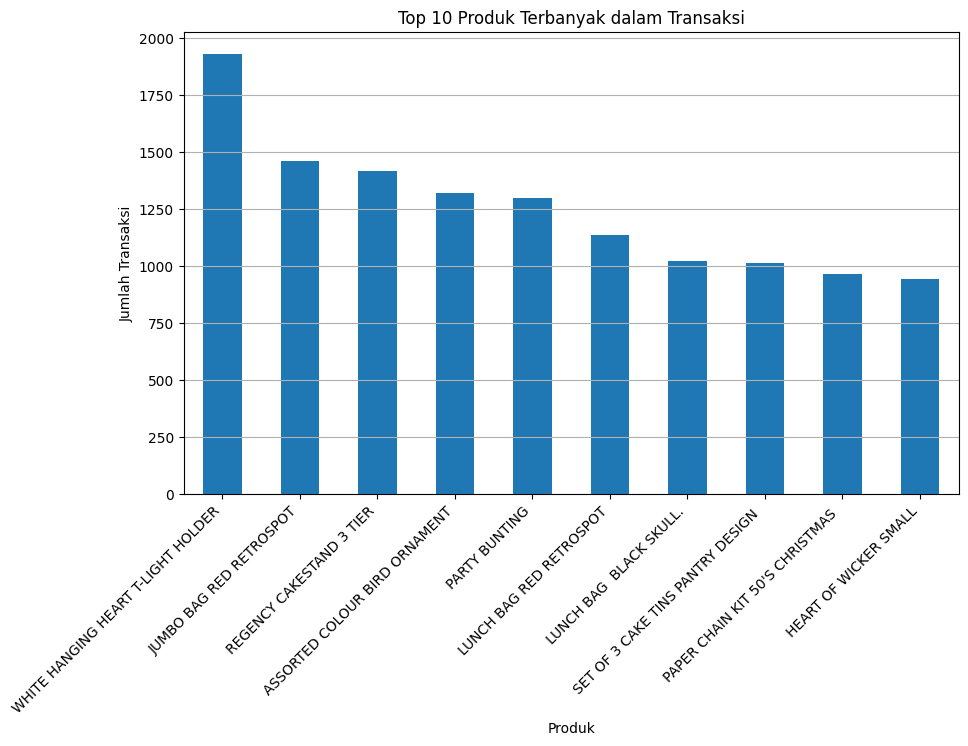

In [30]:
top_10_products = df_uk['Description'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_10_products.plot(kind='bar')
plt.title('Top 10 Produk Terbanyak dalam Transaksi')
plt.xlabel('Produk')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [31]:
# Apriori: Eksperimen dengan min_support=0.02
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
print("\nFrequent Itemsets:\n", frequent_itemsets.head(10))

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



Frequent Itemsets:
       support                              itemsets
184  0.113180  (WHITE HANGING HEART T-LIGHT HOLDER)
79   0.086928             (JUMBO BAG RED RETROSPOT)
149  0.084705            (REGENCY CAKESTAND 3 TIER)
11   0.078097       (ASSORTED COLOUR BIRD ORNAMENT)
123  0.077496                       (PARTY BUNTING)
101  0.067283             (LUNCH BAG RED RETROSPOT)
159  0.060495   (SET OF 3 CAKE TINS PANTRY DESIGN )
94   0.059834             (LUNCH BAG  BLACK SKULL.)
119  0.056770     (PAPER CHAIN KIT 50'S CHRISTMAS )
108  0.056350     (NATURAL SLATE HEART CHALKBOARD )


In [37]:
# Association Rules: min_confidence=0.6
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules = rules[rules['lift'] > 1.2]
print("\nTop Association Rules:\n", rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())



Top Association Rules:
                             antecedents                           consequents  \
0             (JUMBO BAG PINK POLKADOT)             (JUMBO BAG RED RETROSPOT)   
1     (GREEN REGENCY TEACUP AND SAUCER)    (ROSES REGENCY TEACUP AND SAUCER )   
2    (ROSES REGENCY TEACUP AND SAUCER )     (GREEN REGENCY TEACUP AND SAUCER)   
3   (GARDENERS KNEELING PAD KEEP CALM )  (GARDENERS KNEELING PAD CUP OF TEA )   
4  (GARDENERS KNEELING PAD CUP OF TEA )   (GARDENERS KNEELING PAD KEEP CALM )   

    support  confidence       lift  
0  0.030398    0.623153   7.168625  
1  0.028595    0.777778  19.095706  
2  0.028595    0.702065  19.095706  
3  0.027514    0.617251  16.387169  
4  0.027514    0.730463  16.387169  


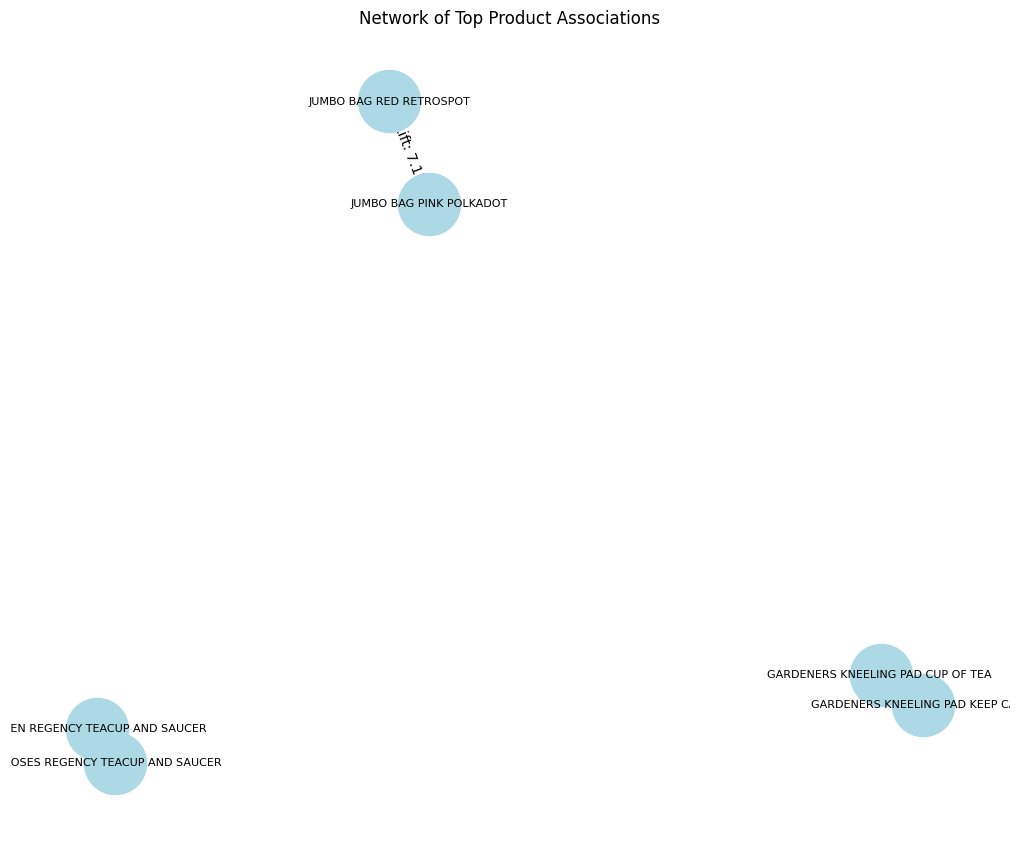

In [36]:
# Visualisasi: Network Graph untuk Rules
G = nx.DiGraph()
for idx, rule in rules.head(5).iterrows():
    for ant in rule['antecedents']:
        for cons in rule['consequents']:
            G.add_edge(ant, cons, weight=rule['lift'])
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=8)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u,v): f"Lift: {d['weight']:.2f}" for u,v,d in G.edges(data=True)})
plt.title('Network of Top Product Associations')
plt.show()


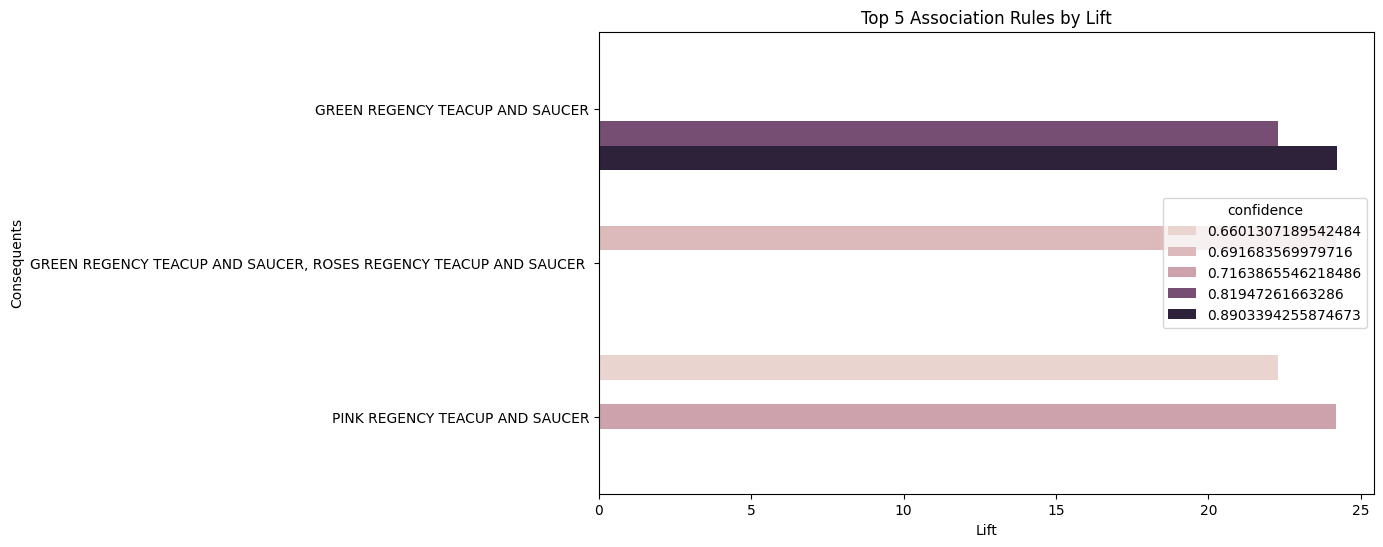

In [39]:
# Visualisasi: Barplot Top 5 Rules
top_rules = rules.nlargest(5, 'lift')
plt.figure(figsize=(10,6))
sns.barplot(x='lift', y=top_rules['consequents'].apply(lambda x: ', '.join(x)), hue='confidence', data=top_rules)
plt.title('Top 5 Association Rules by Lift')
plt.xlabel('Lift')
plt.ylabel('Consequents')
plt.show()

In [47]:
# Rekomendasi untuk produk spesifik
focus_item = 'GREEN REGENCY TEACUP AND SAUCER'
rekomendasi = rules[rules['antecedents'].apply(lambda x: focus_item in x if isinstance(x, frozenset) else False)]
print(f"\nRekomendasi jika beli {focus_item}:\n", rekomendasi[['consequents', 'confidence', 'lift']])


Rekomendasi jika beli GREEN REGENCY TEACUP AND SAUCER:
                            consequents  confidence       lift
1   (ROSES REGENCY TEACUP AND SAUCER )    0.777778  19.095706
9     (PINK REGENCY TEACUP AND SAUCER)    0.660131  22.289120
12  (ROSES REGENCY TEACUP AND SAUCER )    0.844059  20.723028
14    (PINK REGENCY TEACUP AND SAUCER)    0.716387  24.188581


In [48]:
# 4. Time Series Analysis
# Agregasi harian untuk jumlah transaksi
daily_trx = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].nunique().reset_index()
daily_trx.columns = ['Date', 'Transaction_Count']
daily_trx['Date'] = pd.to_datetime(daily_trx['Date'])

In [49]:
# Cek stationarity
adf_result = adfuller(daily_trx['Transaction_Count'])
print("\nADF Test p-value:", adf_result[1])
if adf_result[1] > 0.05:
    daily_trx['Transaction_Count_Diff'] = daily_trx['Transaction_Count'].diff().dropna()
    adf_diff = adfuller(daily_trx['Transaction_Count_Diff'].dropna())
    print("ADF Test p-value after differencing:", adf_diff[1])


ADF Test p-value: 0.47213180071152244
ADF Test p-value after differencing: 5.159372910143998e-13


In [51]:
# Split train-test
train_data = daily_trx['Transaction_Count'][:-30]
test_data = daily_trx['Transaction_Count'][-30:]

# Print shape data train dan test
print("Shape Data Train:", train_data.shape)
print("Shape Data Test:", test_data.shape)

Shape Data Train: (275,)
Shape Data Test: (30,)


In [60]:
# Model ARIMA
arima_model = ARIMA(train_data, order=(1,1,1)).fit()
arima_pred = arima_model.forecast(steps=30)

# Evaluasi model
mae = mean_absolute_error(test_data, arima_pred)
print("MAE:", mae)

MAE: 27.68055526053039


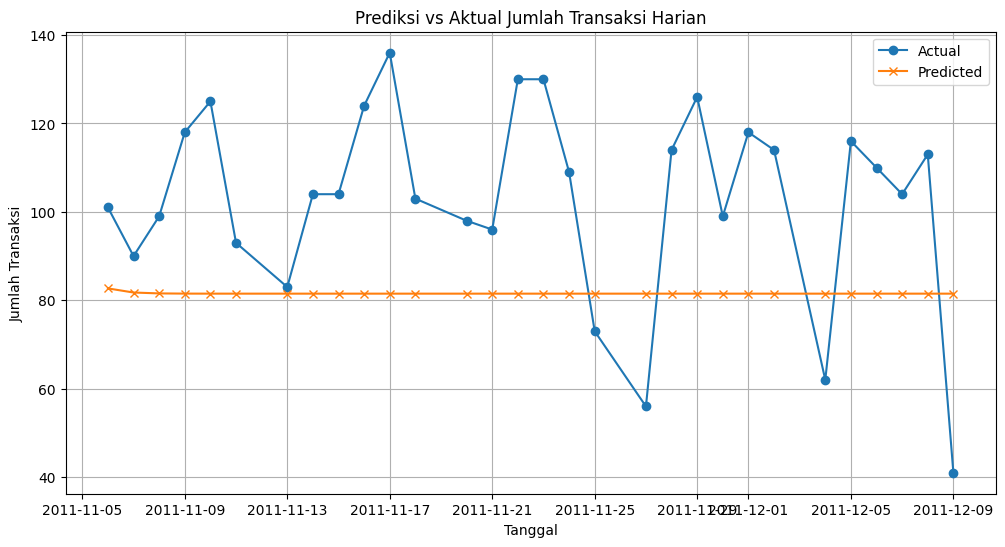

In [55]:
# Visualisasi: Prediksi vs Aktual
plt.figure(figsize=(12,6))
plt.plot(daily_trx['Date'][-30:], test_data, label='Actual', marker='o')
plt.plot(daily_trx['Date'][-30:], arima_pred, label='Predicted', marker='x')
plt.title('Prediksi vs Aktual Jumlah Transaksi Harian')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Transaksi')
plt.legend()
plt.grid()
plt.show()

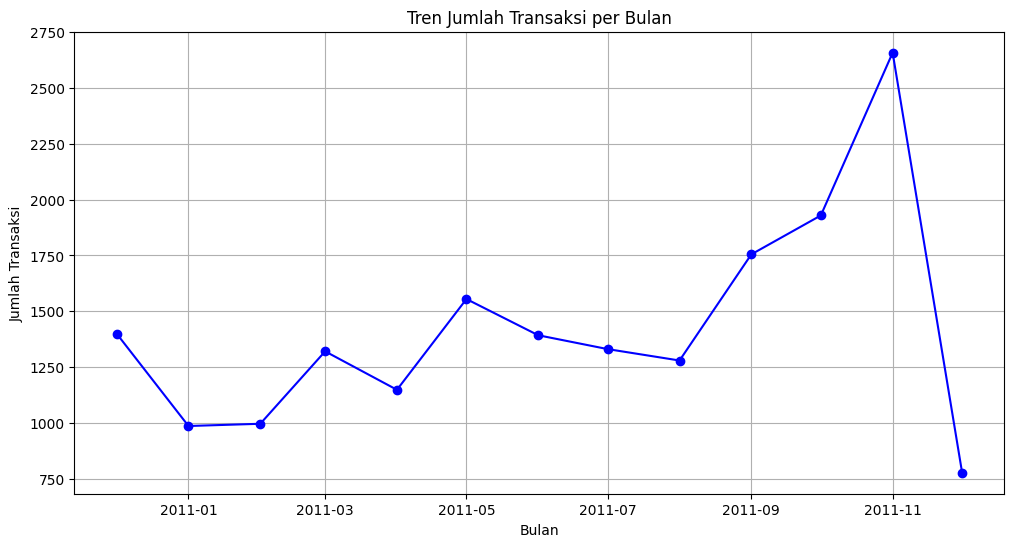

In [56]:
# Visualisasi: Tren Musiman (Bulanan)
monthly_trx = df.groupby(df['InvoiceDate'].dt.to_period('M'))['InvoiceNo'].nunique().reset_index()
monthly_trx['InvoiceDate'] = monthly_trx['InvoiceDate'].dt.to_timestamp()
plt.figure(figsize=(12,6))
plt.plot(monthly_trx['InvoiceDate'], monthly_trx['InvoiceNo'], marker='o', color='blue')
plt.title('Tren Jumlah Transaksi per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Transaksi')
plt.grid()
plt.show()

In [61]:
# 6. Simpan data untuk analisis lanjutan
df.to_csv('online_retail_cleaned.csv', index=False)